<a href="https://colab.research.google.com/github/Neha-Bhivgade/WeIntern_Minor-Project/blob/main/PulseIQ_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap statsmodels tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("online_retail_II.csv")
df.head()

Saving online_retail_II.csv to online_retail_II (1).csv


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
df = df.dropna()  # or fillna()

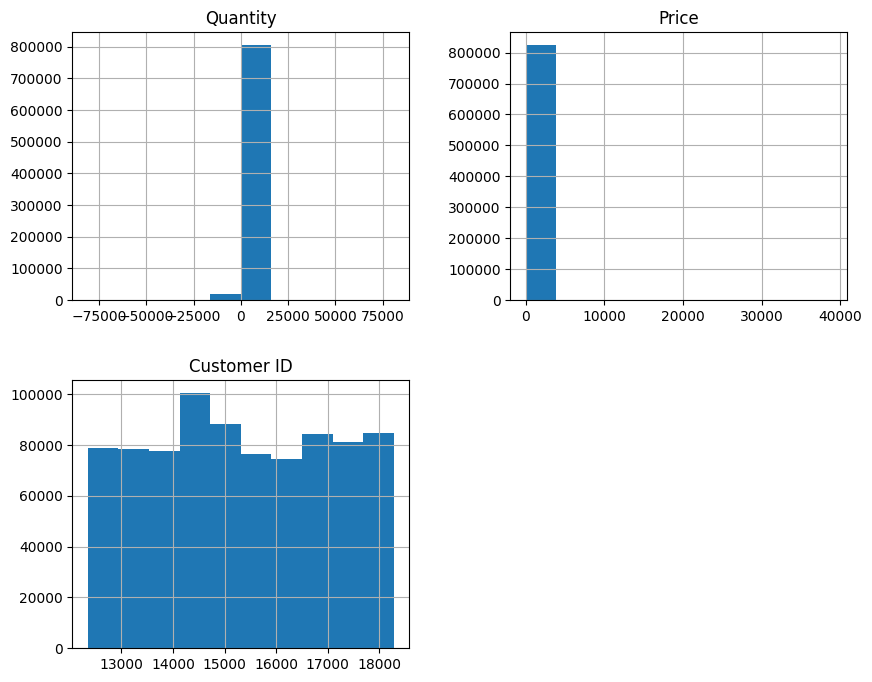

In [ ]:
df.hist(figsize=(10,8))
plt.show()

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')


In [ ]:
df.rename(columns={
    'Customer ID': 'CustomerID',
    'InvoiceDate': 'Date',
    'Price': 'UnitPrice'
}, inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

In [ ]:
df = df.dropna(subset=['CustomerID', 'Quantity', 'UnitPrice'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   Date         805549 non-null  datetime64[ns]
 5   UnitPrice    805549 non-null  float64       
 6   CustomerID   805549 non-null  float64       
 7   Country      805549 non-null  object        
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB


,Quantity,Date,UnitPrice,CustomerID,Revenue
count,805549.000000,805549,805549.000000,805549.000000,805549.000000
mean,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,22.026505
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,4.950000
50%,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,11.850000
75%,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,143.634088,NaN,29.199173,1696.737039,224.041928


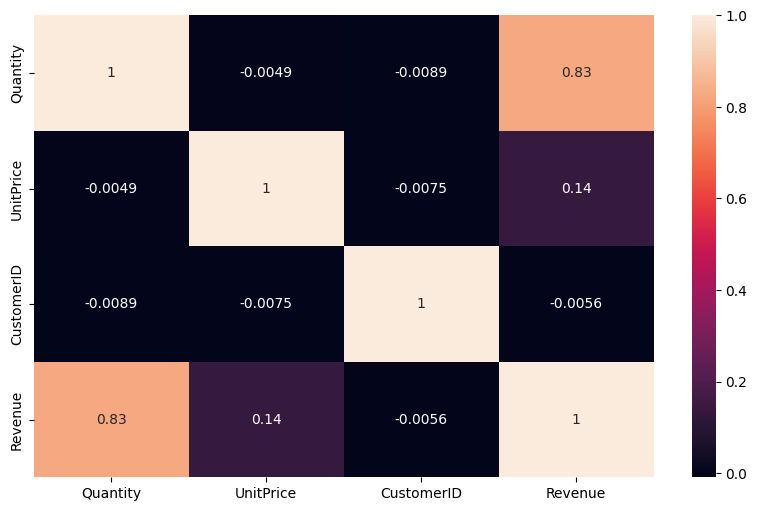

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

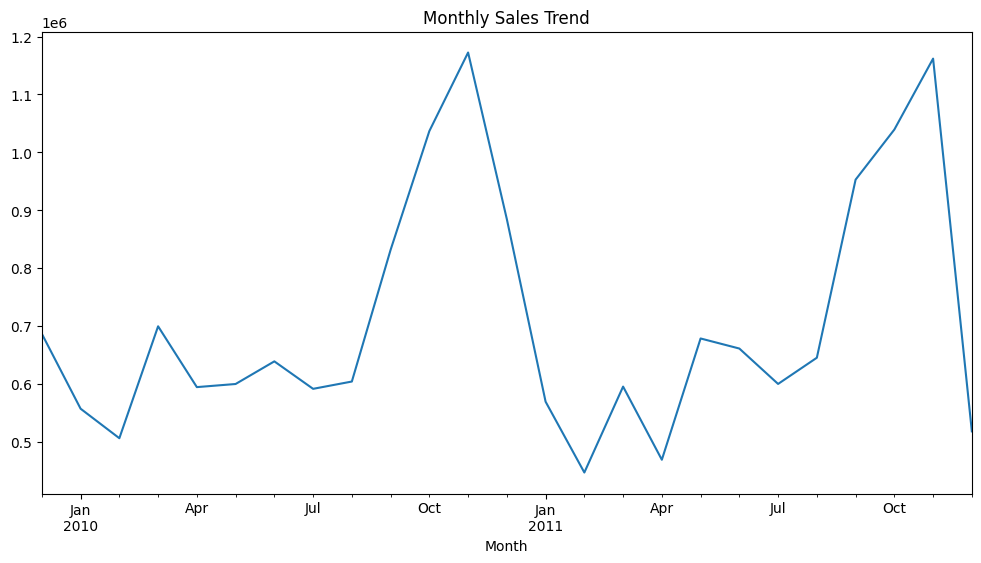

In [ ]:
# Monthly trend (better visualization)
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (df['Date'].max() - x.max()).days,
    'CustomerID': 'count',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,34,77556.46
12347.0,1,253,5633.32
12348.0,74,51,2019.40
12349.0,18,175,4428.69
12350.0,309,17,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

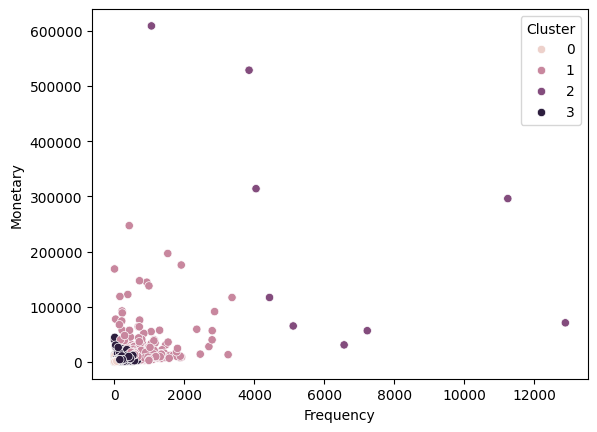

In [ ]:
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm)
plt.show()

In [ ]:
import numpy as np

last_date = df['Date'].max()

rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
[[563   0]
 [  0 613]]


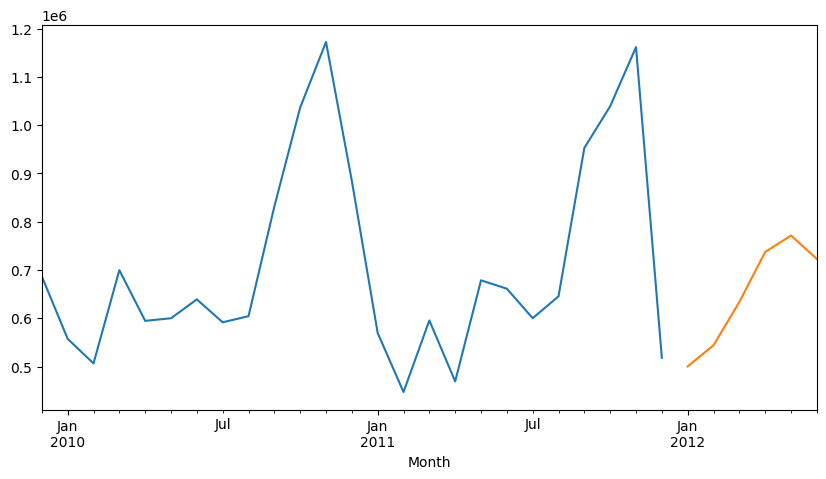

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

ts = monthly_sales.astype(float)

model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

ts.plot(figsize=(10,5))
forecast.plot()
plt.show()